## High-Noise Data from Lagrange Orbits

---

**Problem Setup:** A feedforward neural network (FNN) was trained using Lagrange-orbit data corrupted with 20% noise. Without incorporating the governing physical equations, the network overfits the noisy measurements and does not recover the true underlying orbit.

**Observations and Remarks**

* The problem was rescaled using a similarity transformation such that the orbital period is (T=1), while preserving the form of the governing ODEs.



In [ ]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde

In [ ]:
!pip install tensorflow tf_keras matplotlib numpy scipy

## IMPORTS

In [ ]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

#Training

Set the default float type to float64
Compiling model...
'compile' took 0.004072 s

Training model...

Step      Train loss    Test loss     Test metric
0         [4.21e-02]    [4.22e-02]    []  
1000      [6.98e-03]    [6.80e-03]    []  
2000      [6.37e-03]    [6.07e-03]    []  
3000      [3.06e-03]    [2.68e-03]    []  
4000      [1.05e-03]    [8.31e-04]    []  
5000      [4.20e-04]    [1.84e-04]    []  
6000      [3.58e-04]    [1.29e-04]    []  
7000      [3.19e-04]    [1.29e-04]    []  
8000      [3.08e-04]    [1.45e-04]    []  
9000      [3.03e-04]    [1.55e-04]    []  
10000     [3.01e-04]    [1.62e-04]    []  
11000     [2.99e-04]    [1.62e-04]    []  
12000     [2.98e-04]    [1.64e-04]    []  
13000     [2.96e-04]    [1.66e-04]    []  
14000     [2.95e-04]    [1.70e-04]    []  
15000     [2.93e-04]    [1.71e-04]    []  
16000     [2.92e-04]    [1.76e-04]    []  
17000     [2.89e-04]    [1.81e-04]    []  
18000     [2.86e-04]    [1.86e-04]    []  
19000     [2.83e-04]    [1.92e

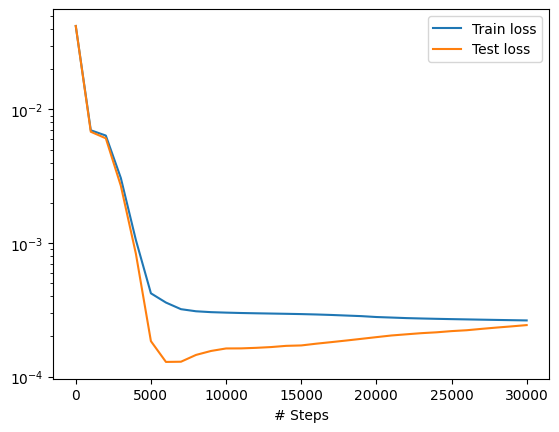

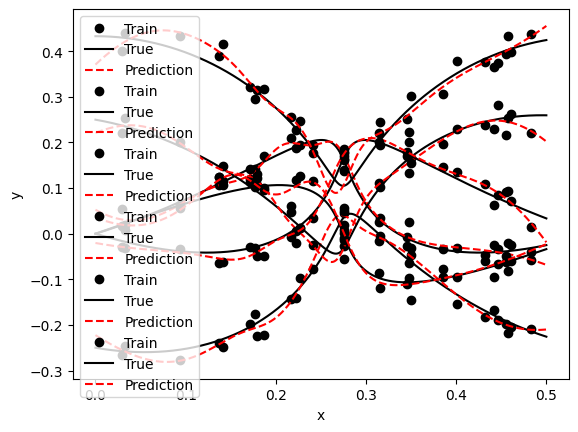

In [ ]:
dde.config.set_default_float("float64")

# --------------------------------------------------
# Reproducibility
# --------------------------------------------------
dde.config.set_random_seed(137)
np.random.seed(137)
tf.random.set_seed(137)

# --------------------------------------------------
# Constants
# --------------------------------------------------
scale = 2
G = 1.0
m = [1.0,1.0,1.0]
endTime = 4/scale**3

layer_size = [1] + [64]*3 + [6]
activation = "tanh"
initializer = "Glorot uniform"

iterations = 30000
learning_rate = 1e-4

eps=1e-9

# --------------------------------------------------
# Initial conditions
# --------------------------------------------------
omega = 0.3

x1_0,y1_0 = -1/scale**2,0
x2_0,y2_0 =  1/scale**2,0
x3_0,y3_0 =  0,np.sqrt(3)/scale**2

vx1_0,vy1_0 = (-np.sqrt(3)/3)*omega*scale , 1*omega*scale
vx2_0,vy2_0 = (-np.sqrt(3)/3)*omega*scale , -1*omega*scale
vx3_0,vy3_0 = (2*np.sqrt(3)/3)*omega*scale , 0

# --------------------------------------------------
# Numerical solution
# --------------------------------------------------
def three_body_numeric(t,y):

    x1,y1,vx1,vy1,x2,y2,vx2,vy2,x3,y3,vx3,vy3 = y

    r12=np.sqrt((x1-x2)**2+(y1-y2)**2+eps)
    r13=np.sqrt((x1-x3)**2+(y1-y3)**2+eps)
    r23=np.sqrt((x2-x3)**2+(y2-y3)**2+eps)

    ax1=G*(m[1]*(x2-x1)/r12**3+m[2]*(x3-x1)/r13**3)
    ay1=G*(m[1]*(y2-y1)/r12**3+m[2]*(y3-y1)/r13**3)

    ax2=G*(m[0]*(x1-x2)/r12**3+m[2]*(x3-x2)/r23**3)
    ay2=G*(m[0]*(y1-y2)/r12**3+m[2]*(y3-y2)/r23**3)

    ax3=G*(m[0]*(x1-x3)/r13**3+m[1]*(x2-x3)/r23**3)
    ay3=G*(m[0]*(y1-y3)/r13**3+m[1]*(y2-y3)/r23**3)

    return [vx1,vy1,ax1,ay1,
            vx2,vy2,ax2,ay2,
            vx3,vy3,ax3,ay3]


t_eval = np.linspace(0,endTime,5000)

y0=[
x1_0,y1_0,vx1_0,vy1_0,
x2_0,y2_0,vx2_0,vy2_0,
x3_0,y3_0,vx3_0,vy3_0
]

sol=solve_ivp(three_body_numeric,(0,endTime),y0,t_eval=t_eval,rtol=1e-10,atol=1e-12,)

x1_n,y1_n = sol.y[0],sol.y[1]
x2_n,y2_n = sol.y[4],sol.y[5]
x3_n,y3_n = sol.y[8],sol.y[9]

# --------------------------------------------------
# Create noisy observations
# --------------------------------------------------
num_obs = 30
noise_level = 0.2

idx = np.sort(np.random.choice(len(t_eval),num_obs,replace=False))

t_obs = t_eval[idx][:,None]

y_obs_true = np.vstack([
x1_n[idx],y1_n[idx],
x2_n[idx],y2_n[idx],
x3_n[idx],y3_n[idx]
]).T

noise = noise_level*np.std(y_obs_true,axis=0)*np.random.randn(*y_obs_true.shape)

y_obs = y_obs_true + noise

# --------------------------------------------------
# Test data (true solution)
# --------------------------------------------------
y_test_true = np.vstack([
x1_n,
y1_n,
x2_n,
y2_n,
x3_n,
y3_n
]).T

# --------------------------------------------------
# Dataset for DeepXDE
# --------------------------------------------------
data = dde.data.DataSet(
    X_train=t_obs,
    y_train=y_obs,
    X_test=t_eval[:,None],
    y_test=y_test_true
)

# --------------------------------------------------
# Neural Network
# --------------------------------------------------
net = dde.nn.FNN(layer_size,activation,initializer)

model = dde.Model(data,net)

model.compile("adam",lr=learning_rate)

losshistory,train_state = model.train(iterations=iterations)
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

#model.compile("L-BFGS")
#losshistory,train_state = model.train()

#Plots -Results

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


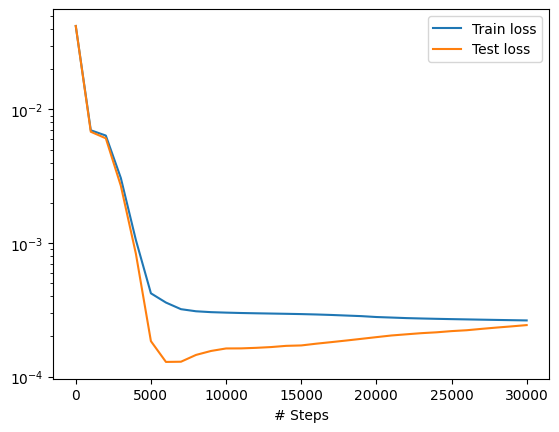

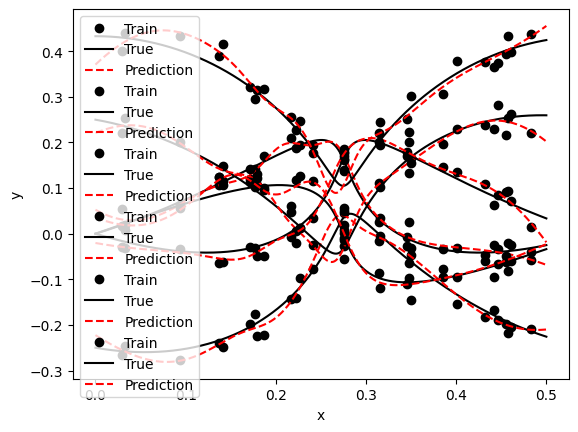

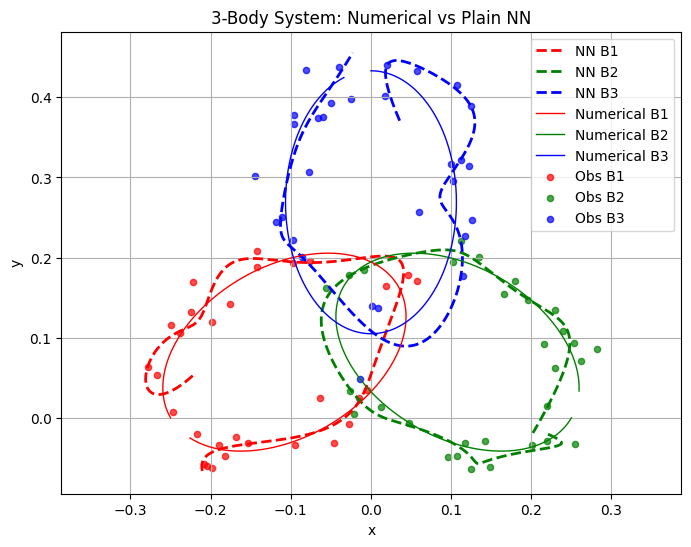


--- L2 Relative Errors ---
Body 1 x error: 8.11e-02
Body 1 y error: 1.29e-01
Body 2 x error: 8.28e-02
Body 2 y error: 1.22e-01
Body 3 x error: 1.78e-01
Body 3 y error: 6.70e-02


In [ ]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)
# --------------------------------------------------
# Predictions
# --------------------------------------------------
t_test = t_eval[:,None]

y_pred = model.predict(t_test)

x1,y1 = y_pred[:,0],y_pred[:,1]
x2,y2 = y_pred[:,2],y_pred[:,3]
x3,y3 = y_pred[:,4],y_pred[:,5]

# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(8,6))

plt.plot(x1,y1,'r--',lw=2,label="NN B1")
plt.plot(x2,y2,'g--',lw=2,label="NN B2")
plt.plot(x3,y3,'b--',lw=2,label="NN B3")

plt.plot(x1_n,y1_n,'r-',lw=1,label="Numerical B1")
plt.plot(x2_n,y2_n,'g-',lw=1,label="Numerical B2")
plt.plot(x3_n,y3_n,'b-',lw=1,label="Numerical B3")

plt.scatter(y_obs[:,0],y_obs[:,1],c='red',s=20,alpha=0.7,label="Obs B1")
plt.scatter(y_obs[:,2],y_obs[:,3],c='green',s=20,alpha=0.7,label="Obs B2")
plt.scatter(y_obs[:,4],y_obs[:,5],c='blue',s=20,alpha=0.7,label="Obs B3")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.title("3-Body System: Numerical vs Plain NN")

plt.show()


# ============================================================
# Optional: Compute relative L2 errors
# ============================================================
interp_x1 = interp1d(t_eval, x1_n, kind='cubic')
interp_y1 = interp1d(t_eval, y1_n, kind='cubic')
interp_x2 = interp1d(t_eval, x2_n, kind='cubic')
interp_y2 = interp1d(t_eval, y2_n, kind='cubic')
interp_x3 = interp1d(t_eval, x3_n, kind='cubic')
interp_y3 = interp1d(t_eval, y3_n, kind='cubic')

x1_err = norm(x1 - interp_x1(t_test[:,0])) / norm(interp_x1(t_test[:,0]))
y1_err = norm(y1 - interp_y1(t_test[:,0])) / norm(interp_y1(t_test[:,0]))
x2_err = norm(x2 - interp_x2(t_test[:,0])) / norm(interp_x2(t_test[:,0]))
y2_err = norm(y2 - interp_y2(t_test[:,0])) / norm(interp_y2(t_test[:,0]))
x3_err = norm(x3 - interp_x3(t_test[:,0])) / norm(interp_x3(t_test[:,0]))
y3_err = norm(y3 - interp_y3(t_test[:,0])) / norm(interp_y3(t_test[:,0]))

print("\n--- L2 Relative Errors ---")
print(f"Body 1 x error: {x1_err:.2e}")
print(f"Body 1 y error: {y1_err:.2e}")
print(f"Body 2 x error: {x2_err:.2e}")
print(f"Body 2 y error: {y2_err:.2e}")
print(f"Body 3 x error: {x3_err:.2e}")
print(f"Body 3 y error: {y3_err:.2e}")

#STATISTICS

In [ ]:
# ============================================================
# STATISTICS
# ============================================================


print("\n")
print("="*60)
print("STATISTICS")
print("="*60)

# ============================================================
# FNN velocities from automatic differentiation
# ============================================================

t_tf = tf.convert_to_tensor(t_test, dtype=tf.float64)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred_tf = model.net(t_tf)

dy_dt = tape.batch_jacobian(y_pred_tf, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:, :, 0].numpy()

# FNN positions
y_pred = y_pred_tf.numpy()

x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# FNN velocities
vx1, vy1 = dy_dt[:,0], dy_dt[:,1]
vx2, vy2 = dy_dt[:,2], dy_dt[:,3]
vx3, vy3 = dy_dt[:,4], dy_dt[:,5]

# ============================================================
# Numerical solution
# ============================================================

x1_n  = sol.y[0]
y1_n  = sol.y[1]
vx1_n = sol.y[2]
vy1_n = sol.y[3]

x2_n  = sol.y[4]
y2_n  = sol.y[5]
vx2_n = sol.y[6]
vy2_n = sol.y[7]

x3_n  = sol.y[8]
y3_n  = sol.y[9]
vx3_n = sol.y[10]
vy3_n = sol.y[11]

# ============================================================
# TRAIN / TEST LOSS
# ============================================================

train_losses = np.array(losshistory.loss_train)
test_losses  = np.array(losshistory.loss_test)

final_train_loss = np.sum(train_losses[-1])
final_test_loss  = np.sum(test_losses[-1])


LDATA = final_train_loss

print(f"Final Training Loss : {final_train_loss:.2e}")
print(f"Final Test Loss     : {final_test_loss:.2e}")
print(f"Data Loss           : {LDATA:.2e}")

# ============================================================
# 2. POSITION ERRORS - RMSE
# ============================================================

err1 = np.sqrt((x1 - x1_n)**2 + (y1 - y1_n)**2)
err2 = np.sqrt((x2 - x2_n)**2 + (y2 - y2_n)**2)
err3 = np.sqrt((x3 - x3_n)**2 + (y3 - y3_n)**2)

rmse1 = np.sqrt(np.mean(err1**2))
rmse2 = np.sqrt(np.mean(err2**2))
rmse3 = np.sqrt(np.mean(err3**2))

RMSE = np.sqrt(np.mean(
    np.concatenate([
        err1**2,
        err2**2,
        err3**2
    ])
))

print("\nPosition RMSE")
print("-----------------------------")
print(f"Body 1 : {rmse1:.2e}")
print(f"Body 2 : {rmse2:.2e}")
print(f"Body 3 : {rmse3:.2e}")
print(f"Global : {RMSE:.2e}")

print("\nMaximum Position Error")
print("-----------------------------")
print(f"Body 1 : {np.max(err1):.2e}")
print(f"Body 2 : {np.max(err2):.2e}")
print(f"Body 3 : {np.max(err3):.2e}")

max_pos_error = max(
    np.max(err1),
    np.max(err2),
    np.max(err3)
)
print(f"Global Max Position error : {max_pos_error:.2e}")

# ============================================================
# 3. ENERGY
# ============================================================



def total_energy(x1,y1,vx1,vy1,
                 x2,y2,vx2,vy2,
                 x3,y3,vx3,vy3,
                 G=1.0,
                 m=(1.0,1.0,1.0),
                 eps=0.0):

    KE = (
        0.5*m[0]*(vx1**2+vy1**2)
        +0.5*m[1]*(vx2**2+vy2**2)
        +0.5*m[2]*(vx3**2+vy3**2)
    )

    r12 = np.sqrt((x1-x2)**2+(y1-y2)**2+eps)
    r13 = np.sqrt((x1-x3)**2+(y1-y3)**2+eps)
    r23 = np.sqrt((x2-x3)**2+(y2-y3)**2+eps)

    PE = (
        -G*m[0]*m[1]/r12
        -G*m[0]*m[2]/r13
        -G*m[1]*m[2]/r23
    )

    return KE + PE


E = total_energy(
    x1,y1,vx1,vy1,
    x2,y2,vx2,vy2,
    x3,y3,vx3,vy3,
    G,m,eps
)

E0 = E[0]

DE_E0 = np.max(np.abs(E-E0))/abs(E0)

print("\nEnergy Conservation")
print("-----------------------------")
print(f"FNN ΔE/E0 : {DE_E0:.2e}")

E_num = total_energy(
    x1_n, y1_n, vx1_n, vy1_n,
    x2_n, y2_n, vx2_n, vy2_n,
    x3_n, y3_n, vx3_n, vy3_n,
    G, m, eps
)

E0_num = E_num[0]

DE_E0_num = np.max(np.abs(E_num-E0_num))/abs(E0_num)


print("-----------------------------")
print(f"Numerical ΔE/E0 : {DE_E0_num:.2e}")

# ============================================================
# 4. LINEAR MOMENTUM DRIFT
# ============================================================

Px = m[0]*vx1 + m[1]*vx2 + m[2]*vx3
Py = m[0]*vy1 + m[1]*vy2 + m[2]*vy3

DeltaP = np.max(
    np.sqrt(
        (Px - Px[0])**2 +
        (Py - Py[0])**2
    )
)

print("\nLinear Momentum")
print("-----------------------------")
print(f"FNN Max Momentum Drift : {DeltaP:.2e}")

Px_n = m[0]*vx1_n + m[1]*vx2_n + m[2]*vx3_n
Py_n = m[0]*vy1_n + m[1]*vy2_n + m[2]*vy3_n

DeltaP_n = np.max(
    np.sqrt(
        (Px_n - Px_n[0])**2 +
        (Py_n - Py_n[0])**2
    )
)


print("-----------------------------")
print(f"Numerical Max Momentum Drift : {DeltaP_n:.2e}")


# ============================================================
# 5. ANGULAR MOMENTUM
# ============================================================

L = (
      m[0]*(x1*vy1-y1*vx1)
    + m[1]*(x2*vy2-y2*vx2)
    + m[2]*(x3*vy3-y3*vx3)
)

L0 = L[0]

DL_L0 = np.max(np.abs(L-L0))/max(abs(L0),1e-15)

print("\nAngular Momentum Conservation")
print("-----------------------------")
print(f"ΔL/L0 : {DL_L0:.2e}")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*60)
print("SUMMARY")
print("="*60)

print(f"Final Training Loss               : {final_train_loss:.2e}")
print(f"Final Test Loss                   : {final_test_loss:.2e}")
print(f"Data Loss                         : {LDATA:.2e}")
print(f"Global Max Position error         : {max_pos_error:.2e}")
print(f"Position RMSE                     : {RMSE:.2e}")
print(f"FNN ΔE/E0                        : {DE_E0:.2e}")
print(f"Numerical ΔE/E0                   : {DE_E0_num:.2e}")
print(f"FNN Max Momentum Drift ΔP        : {DeltaP:.2e}")
print(f"Numerical Max Momentum Drift ΔP   : {DeltaP_n:.2e}")
print(f"ΔL/L0                             : {DL_L0:.2e}")



STATISTICS
Final Training Loss : 2.63e-04
Final Test Loss     : 2.43e-04
Data Loss           : 2.63e-04

Position RMSE
-----------------------------
Body 1 : 1.96e-02
Body 2 : 1.92e-02
Body 3 : 2.65e-02
Global : 2.20e-02

Maximum Position Error
-----------------------------
Body 1 : 5.94e-02
Body 2 : 7.77e-02
Body 3 : 7.18e-02
Global Max Position error : 7.77e-02

Energy Conservation
-----------------------------
FNN ΔE/E0 : 5.42e+00
-----------------------------
Numerical ΔE/E0 : 9.48e-10

Linear Momentum
-----------------------------
FNN Max Momentum Drift : 4.40e+00
-----------------------------
Numerical Max Momentum Drift : 4.93e-15

Angular Momentum Conservation
-----------------------------
ΔL/L0 : 3.05e+00


SUMMARY
Final Training Loss               : 2.63e-04
Final Test Loss                   : 2.43e-04
Data Loss                         : 2.63e-04
Global Max Position error         : 7.77e-02
Position RMSE                     : 2.20e-02
FNN ΔE/E0                        : 5.42